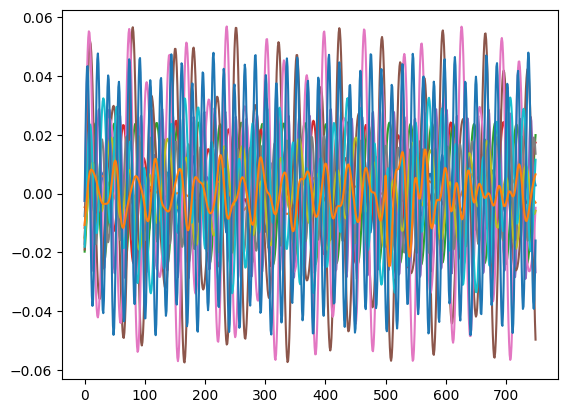

In [1]:
# Load data
import numpy as np
import matplotlib.pyplot as plt

def gen_timeseries(length=750, num_waves=2):
    base = (np.random.rand(1) - 0.5) * np.ones((length,))

    for _ in range(num_waves):
        base += np.sin(np.arange(length) * np.random.rand(1) * 0.4  - np.random.rand(1)) * np.random.rand(1) * 0.05

    return base


xs = []
for i in range(100):

    x = np.stack([gen_timeseries() for _ in range(12)])

    x -= np.mean(x, axis=1, keepdims=True)
    # x = np.std(x, axis=1, keepdims=True)

    # Make x[11] dependent on 0, 1, 2
    x[11] = np.mean(x[:3, :], axis=0)
    x_pre = np.copy(x.T)

    # Make x[11] dependent on 3, 4, 5 after the timestep
    x[11, 500:] = np.linspace(0, 1, 250) * x[11, 500:] + (1 - np.linspace(0, 1, 250)) * np.mean(x[3:6, 500:], axis=0)
    
    x = x[:, np.all(np.isfinite(x), axis=0)].T

    
    xs.append(x)

plt.plot(x)
plt.show()

In [2]:
from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for sr in tqdm(np.linspace(0.2, 0.8, 10)[::-1]):
    for iw in np.linspace(0.25, 1.0, 10):
        for l in np.linspace(0.5, 0.95, 10):
            network = RhythmicNetwork(
                # Tune Rhythmic Sharing
                link_strength_change_ratio=0.5,
                omega0=0.05,
                epsilon1=-0.12,
                epsilon2=0.25,
                # Tune ESN
                input_dims=12,
                spectral_radius=sr,
                input_weight=iw,
                average_degree_nodes=5,
                num_nodes=75,
                leakage=l
            )

            network.train(x_pre.T[:, :-100])
            pred = network.predict(x_pre.T[:, -110:], warmup_time=10)
            mse = np.mean(np.square((pred[:, 1:] - x_pre.T[:, -100:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
        
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 465.5398983887 (np.float64(0.8), np.float64(0.25), np.float64(0.5))
New best 262.8000149956 (np.float64(0.8), np.float64(0.3333333333333333), np.float64(0.5))
New best 168.4979122410 (np.float64(0.8), np.float64(0.41666666666666663), np.float64(0.5))
New best 117.4257213372 (np.float64(0.8), np.float64(0.5), np.float64(0.5))
New best 86.1980715125 (np.float64(0.8), np.float64(0.5833333333333333), np.float64(0.5))
New best 66.2087820110 (np.float64(0.8), np.float64(0.6666666666666666), np.float64(0.5))
New best 52.3708012223 (np.float64(0.8), np.float64(0.75), np.float64(0.5))
New best 42.3644863022 (np.float64(0.8), np.float64(0.8333333333333333), np.float64(0.5))
New best 35.0951305500 (np.float64(0.8), np.float64(0.9166666666666666), np.float64(0.5))
New best 29.4089346413 (np.float64(0.8), np.float64(1.0), np.float64(0.5))


 10%|████████▎                                                                          | 1/10 [00:29<04:27, 29.77s/it]

New best 28.3524591460 (np.float64(0.7333333333333334), np.float64(0.9166666666666666), np.float64(0.5))
New best 23.7874655990 (np.float64(0.7333333333333334), np.float64(1.0), np.float64(0.5))


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [04:57<00:00, 29.80s/it]


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

New best 0.9818928410 (np.float64(0.25), np.float64(-0.2), np.float64(0.6111111111111112), np.float64(1.0))


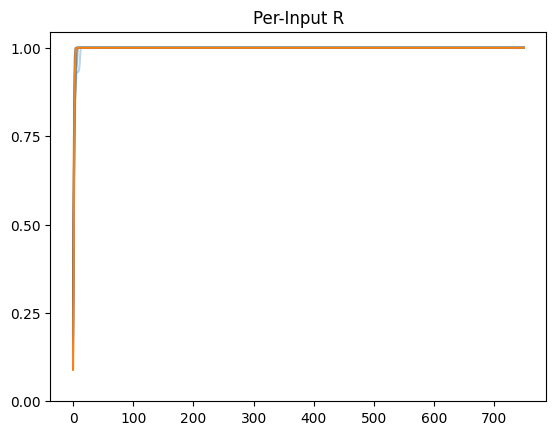

 10%|████████▎                                                                          | 1/10 [00:30<04:33, 30.35s/it]

New best 1.2227901494 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(1.0))


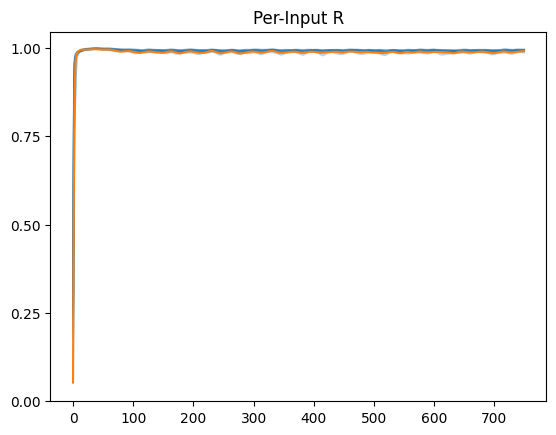

New best 1.2528301614 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(0.046415888336127774))


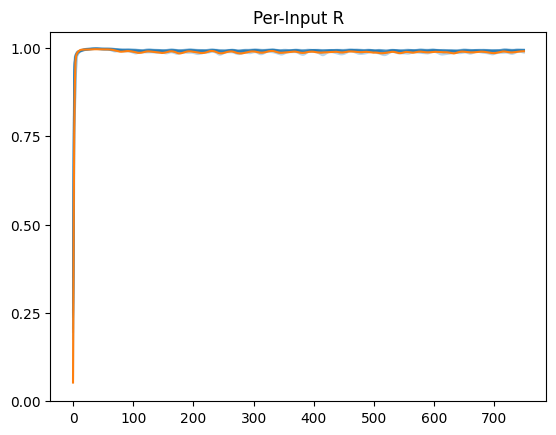

New best 1.2676151037 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(0.01))


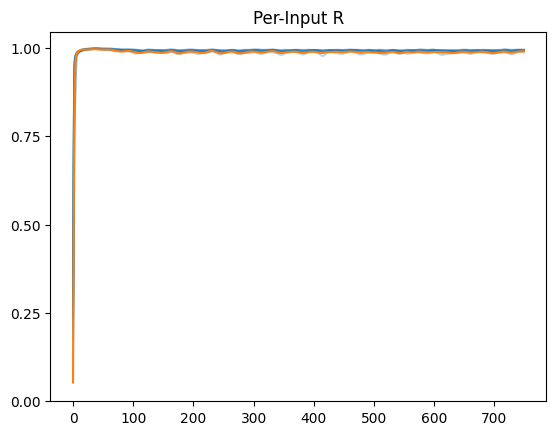

New best 1.3360155685 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(0.004641588833612777))


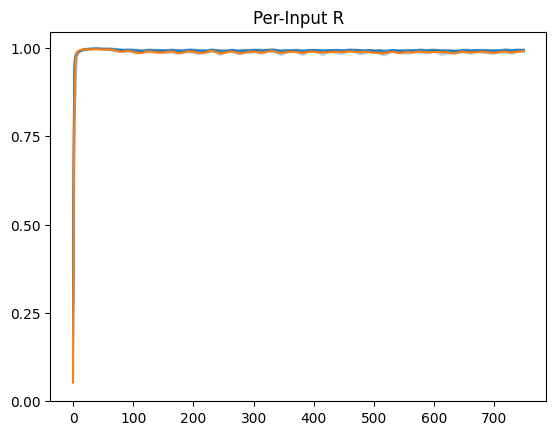

New best 1.5162240362 (np.float64(0.25), np.float64(-0.1888888888888889), np.float64(0.7222222222222222), np.float64(0.0021544346900318843))


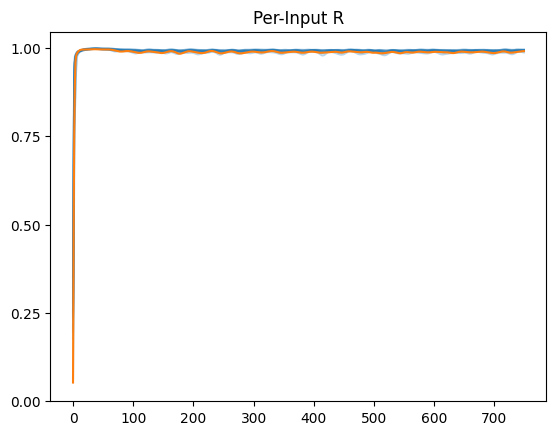

 30%|████████████████████████▉                                                          | 3/10 [01:31<03:34, 30.61s/it]

New best 1.6309871780 (np.float64(0.25), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(0.21544346900318823))


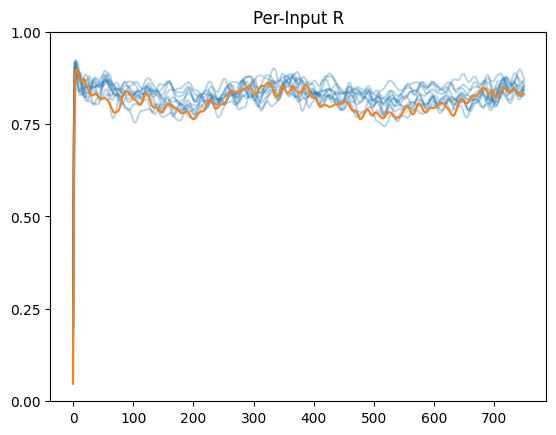

New best 1.7391661856 (np.float64(0.25), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(0.01))


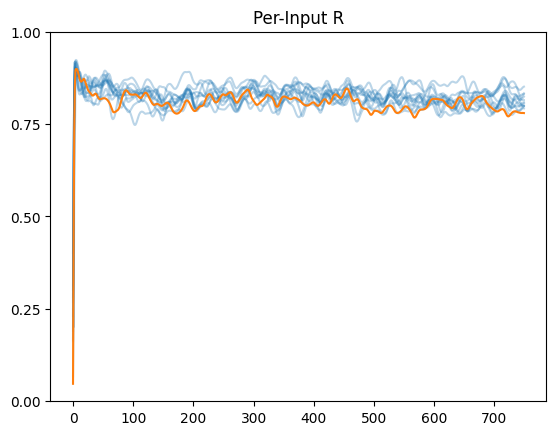

 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [04:07<01:01, 30.94s/it]

New best 1.7445684961 (np.float64(0.25), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.21544346900318823))


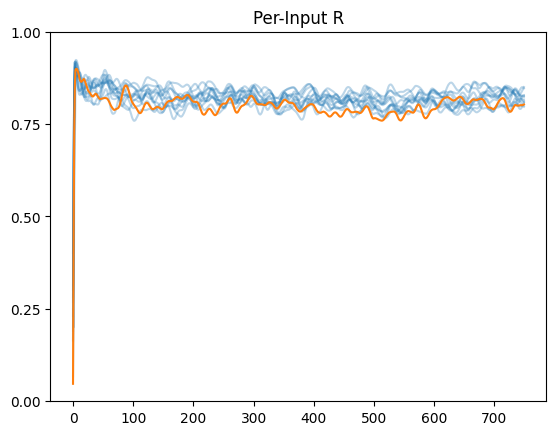

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [04:38<00:31, 31.03s/it]

New best 1.7841351120 (np.float64(0.25), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(1.0))


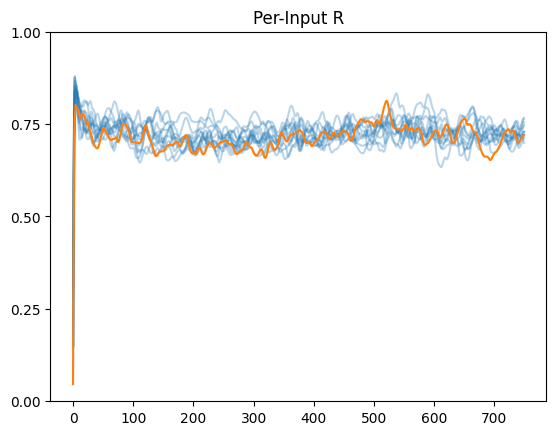

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [04:42<00:31, 31.86s/it]

New best 1.9394872343 (np.float64(0.3333333333333333), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.1))


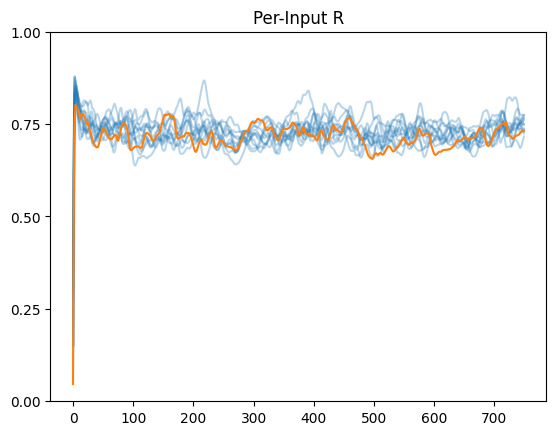

 30%|████████████████████████▉                                                          | 3/10 [01:34<03:40, 31.56s/it]

New best 1.9909052756 (np.float64(0.41666666666666663), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(0.01))


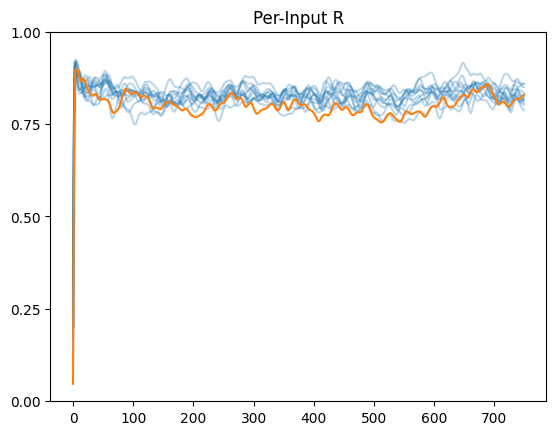

 30%|████████████████████████▉                                                          | 3/10 [01:32<03:36, 30.97s/it]

New best 2.0658308768 (np.float64(0.5), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(0.1))


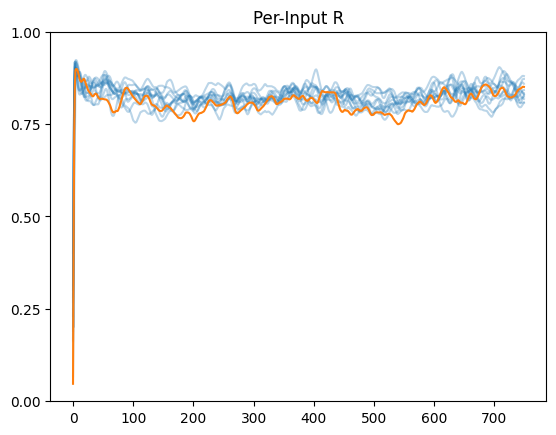

 80%|██████████████████████████████████████████████████████████████████▍                | 8/10 [04:05<01:00, 30.48s/it]

New best 2.1029881319 (np.float64(0.5), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.46415888336127775))


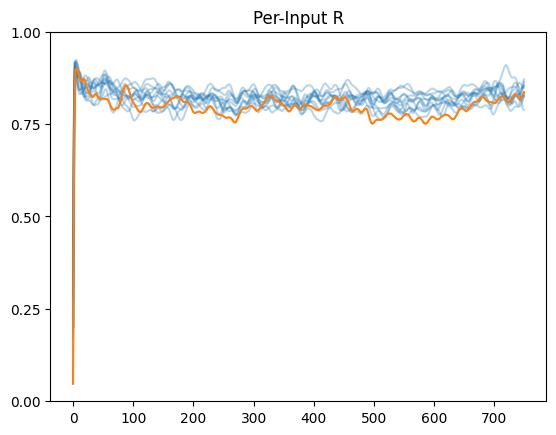

New best 2.5536720778 (np.float64(0.5), np.float64(-0.11111111111111112), np.float64(0.6111111111111112), np.float64(0.046415888336127774))


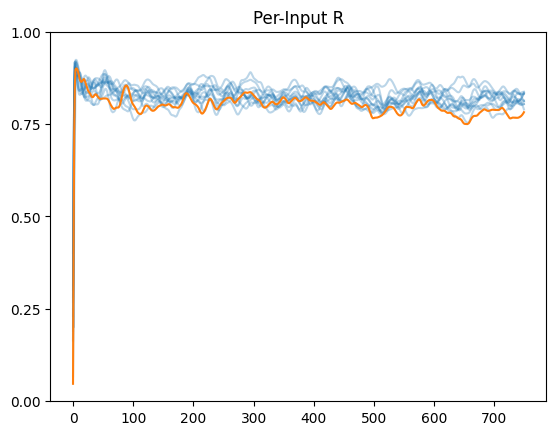

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [04:36<00:30, 30.67s/it]

New best 2.7988737740 (np.float64(0.5), np.float64(-0.1), np.float64(0.6111111111111112), np.float64(0.21544346900318823))


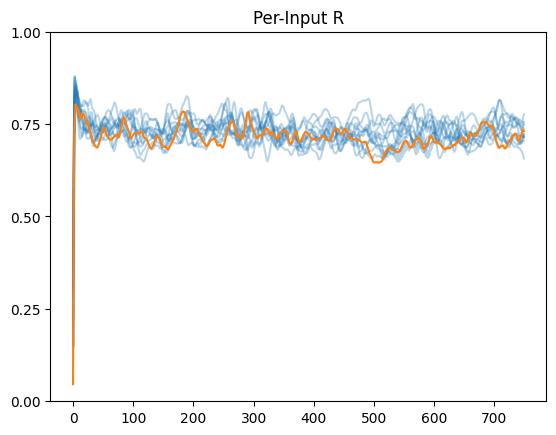

 30%|████████████████████████▉                                                          | 3/10 [01:33<03:38, 31.26s/it]

New best 3.5239622092 (np.float64(0.6666666666666666), np.float64(-0.16666666666666669), np.float64(0.7222222222222222), np.float64(1.0))


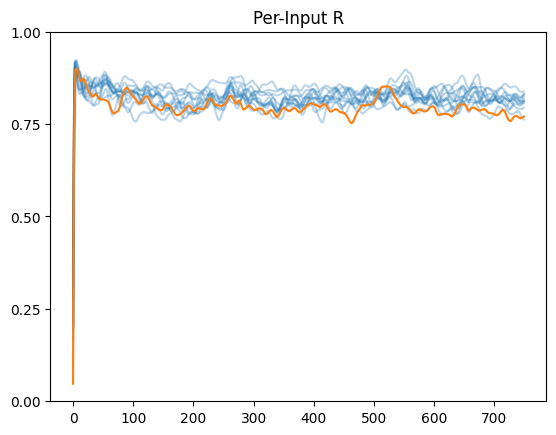

 10%|████████▎                                                                          | 1/10 [00:38<05:42, 38.01s/it]


KeyboardInterrupt: 

In [3]:
best_difference = 0
for lsr in np.linspace(0.25, 1, 10):
    for e1 in tqdm(np.linspace(-0.2, -0.1, 10)):
        for o in np.logspace(-3, 0, 10)[::-1]:
            for e2 in np.linspace(0.5, 1.5, 10)[:-1]:
                network = RhythmicNetwork(
                    # Tune Rhythmic Sharing
                    dt=10,
                    link_strength_change_ratio = lsr,
                    omega0 = o,
                    epsilon1 = e1,
                    epsilon2 = e2,
                    # Set ESN
                    input_dims=12,
                    spectral_radius=best_esn_param[0],
                    input_weight=best_esn_param[1],
                    average_degree_nodes=5,
                    num_nodes=75,
                    leakage=best_esn_param[2],
                )

                network.train(x.T, warmup_time=0)
                r = network.get_input_parameters()[0]
    
                # diff = np.abs(np.mean(r.T[300:500, 11]) - np.mean(r.T[500:, 11])) #/np.mean(r.T[:250])
                diff = np.abs(np.mean(r.T[300:500, 11]) - np.mean(r.T[500:550, 11]))/np.std(r.T[300:500, 11])
                
                if diff > best_difference and np.mean(r.T[300:500]) > 0.7: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T[:, :11], color="tab:blue", alpha=0.3)
                    plt.plot(network.get_input_parameters()[0].T[:, 11], color="tab:orange")
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [4]:
network = RhythmicNetwork(
    # Tune Rhythmic Sharing
    dt=10,
    link_strength_change_ratio = best_param_rhy[0],
    omega0 = best_param_rhy[3],
    epsilon1 = best_param_rhy[1],
    epsilon2 = best_param_rhy[2],
    # Set ESN
    input_dims=12,
    spectral_radius=best_esn_param[0],
    input_weight=best_esn_param[1],
    average_degree_nodes=5,
    num_nodes=75,
    leakage=best_esn_param[2],
)

network.train(x.T, warmup_time=0)
r = network.get_input_parameters()[0]

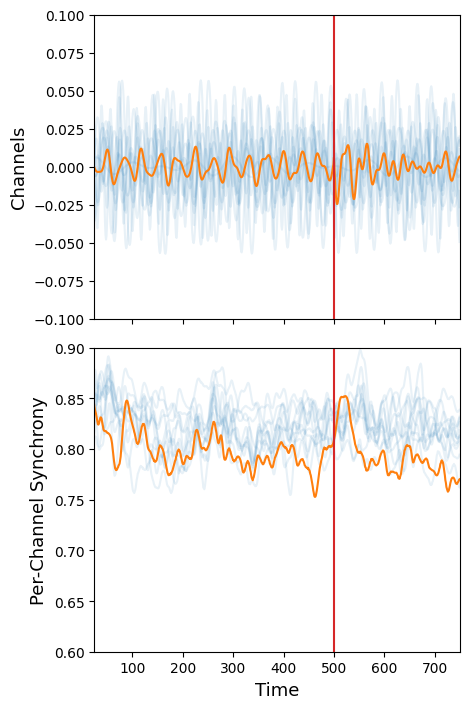

In [5]:
# Generate figures
SMALL_SIZE = 10
MEDIUM_SIZE = 13
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6.4 * 1.5 * 0.5, 4.8 * 1.5))

axs[0].plot(x[:, :11], alpha=0.1, color="tab:blue")
axs[0].plot(x[:, 11], color="tab:orange")
axs[0].axvline(500, color="tab:red")
axs[0].set_ylabel("Channels")
axs[0].set_xlim(25, 750)
axs[0].set_ylim(-0.1, 0.1)

axs[1].plot(r.T[:, :11], alpha=0.1, color="tab:blue")
axs[1].plot(r.T[:, 11], color="tab:orange")
axs[1].axvline(500, color="tab:red")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Per-Channel Synchrony")
axs[1].set_ylim(0.6, 0.9)
axs[0].set_xlim(25, 750)

# fig.suptitle("Imperceptible Sensor Faults have Large Effects on Synchrony")

plt.tight_layout()
plt.savefig("toy_2.pdf")
plt.show()